# **Predictive Capacity Planning and Manufacturing Trend Analysis for Bag Production (2018 – 2023)**

Analyzing past production data is essential for both infrastructure scalability and manufacturing efficiency. This study examines six years' worth of biweekly production data for a bag product line, estimating long-term trends and looking at monthly growth rates, especially during the economic downturns of 2020 and 2021. In order to provide insights for capital expenditure decisions, such as forecasting when manufacturing volumes would exceed current storage capacity and signal the need for a new warehouse, the analysis converts raw outputs into a numerical framework.

### MAIN OBJECTIVES:
*   Estimate long-term manufacturing trends and monthly growth rates, with a focus on economic downturns.
*   Convert raw biweekly production outputs into a structured numerical framework for scalability.
*   Forecast future manufacturing volumes to optimize capital expenditure and warehouse capacity planning.

# **PROBLEM 1.**
*"You must find the trend on the bag’s production from the data. You must provide a mathematical model that can explain the production’s trend accurately. Since your supervisor want an accurate model, you must avoid any linear approach to build the trend model."*

### **EXPLANATION:**
We will read and import the CSV file containing monthly bag production values. The response (dependent) variable $y$ represents the production quantity for each month, extracted from the first row of the dataset while the predictor (independent) variable $x$ represents the time index ranging from 1 to n, where n is the number of months.


To model the relationship between production and time, we thought polynomial regresion is the best approach. For each degree $d \in \{2, 3, 4\}$, a polynomial model was fitted using least squares via the np.polyfit() function, which estimates the coefficients that minimize the sum of squared residueals. The resulting polynomial was evaluated at each time index x to obtain prediction values $\hat{y}$.

$$y = \beta_0 + \beta_1x + \cdots + \beta_dx^d$$

Model performance was evaluated using the coefficient of determination ($R^2$), which measures the proprotion of variance in production explained by the model. The model with the highest $R^2$ among degrees 2, 3, and 4 was selected by the best-fitting model. For the best model, the polynomail degree and corresponding coefficients were stored for further reporting and interpretations.


To visually compare the model fits, three subplots were generated, each corresponding to one polynomial degree (2, 3, 4). Observed production values were plotted as scatter points against the month index. For each model, a smooth polynomial curve was plotted over a dense grid of $x$ values (np.linspace()) to illustrate the trend captured by the model. Each subplot displays the model degree and its $R^2$ score value in the title, enabling direct visual and numerical comparison of model performance.

The model with the highest $R^2$ was identified as a degree
d=bestDeg polynomial. Its coefficients $\beta_i$ were reported, allowing the explicit equation of the fitted polynomial to be written. This model achieved an R² of approximately $R^2$, indicating that it explains about` 0.9958%` of the variability in monthly production.

Best Mode Coefficients (Degree 4)
x^4: 0.000029
x^3: -0.004446
x^2: 0.641969
x^1: 22.005505
Constant: 1937.026376

The most accurate model is Degree 4 with R2 score of 0.9958


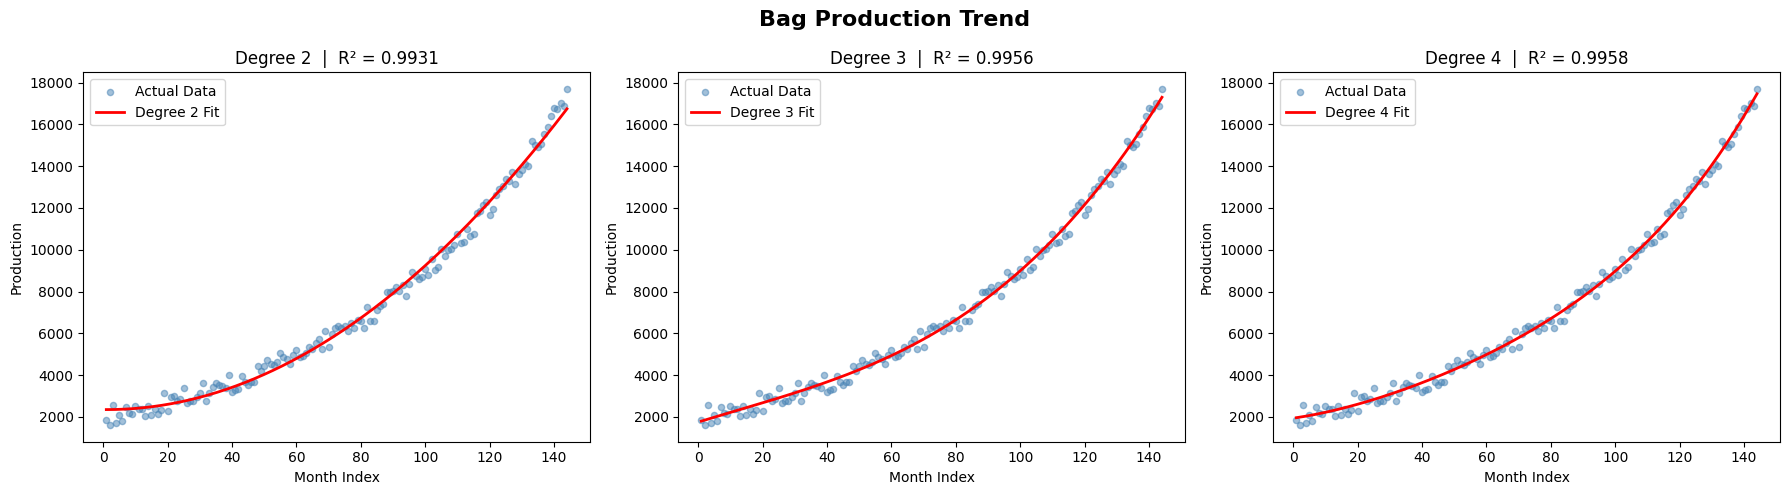

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score

#1. Read CSV file
csvFile = pd.read_csv("whatdoinamethis.csv")

#2. Extract production values
y = csvFile.iloc[0].values.astype(float) #production values from the first (and only) row
x = np.arange(1, len(y) + 1) #time index for months (M1, M2, and so on)

#3. Implement polynomial regression
#3.1. Comparing degree 2, 3 and 4 because good lord that was a mess
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Bag Production Trend', fontsize=16, fontweight="bold")

bestDeg = None
bestR2 = -1
bestCoeffs = None

#3.2. Iterate through three polynomial degrees: 2 (Quadratic), 3 (Cubic), 4 (Quartic)z
for i, degree in enumerate([2, 3, 4]):
  coefficients = np.polyfit(x, y, degree)
  polynomial = np.poly1d(coefficients)
  yPred = polynomial(x)
  r2 = r2_score(y, yPred)

  #3.3. Selection logic
  if r2 > bestR2:
    bestR2 = r2
    bestDeg = degree
    bestCoeffs = coefficients

  #3.4. Visualization that generates three subplots
  xPlot = np.linspace(min(x), max(x), 300)
  yPlot = polynomial(xPlot)

  axes[i].scatter(x, y, color='steelblue', alpha=0.5, s=20, label='Actual Data')
  axes[i].plot(xPlot, yPlot, color='red', linewidth=2, label=f'Degree {degree} Fit')
  axes[i].set_title(f"Degree {degree}  |  R² = {r2:.4f}")
  axes[i].set_xlabel("Month Index")
  axes[i].set_ylabel("Production")
  axes[i].legend()

print("=" * 60)
print(f"Best Mode Coefficients (Degree {bestDeg})")
print("=" * 60)
for i, c in enumerate(bestCoeffs):
  power = bestDeg - i
  if power > 0:
    print(f"x^{power}: {c:.6f}")
  else:
    print(f"Constant: {c:.6f}")

print()
print(f"The most accurate model is Degree {bestDeg} with R2 score of {bestR2:.4f}")

plt.tight_layout()
plt.show()

# **PROBLEM 2.**
*"Since you’ll need to process the data using a computer program, you’ll need to convert the mathematical model from problem #1 to its numerical form (approximation). This is done so that the mathematical model can be calculated by the program easily. Since accuracy is still important, make sure that your conversion is accurate as possible. Provide an explanation to your supervisor about the accuracy of your conversion."*

### **EXPLANATION:**
The best-performing model from the previous analysis was the 4th degree polynomial, so the degree was fixed for the forecasting step. The polynomial coefficients were recalculated for the 4th degree using least squares regression via np.polyfit, based on the full set of observed monthly production data.

The estimated polynomial was implemented as a callable function $f(x)$ using np.poly1d, allowing production to be predicted for any given month index. The function, bagProdModel, takes a month index as input and returns the corresponding model-based production estimate.

To make the model interpretable, the estimated polynomial was converted into an explicit algebraic expression of the form:

$f(x) = a_4x^4 + a_3x^3 + a_2x^2 + a_1x + a_0$

It iterates over each coefficient, constructs the corresponding term (including the sign, coefficient value, and power of x) and print the full numerical form of the model. Coefficients with absolute value below a small threshold ($10^{-6}$) are omitted to avoid displaying terms that are effectively zero.

The model was then used to generate forecasts for the next 12 months beyond the observed period. The future time indices were defined as consecutive integers starting immediately after the last obsevred month and extending 12 months ahead. For each future index, the function bagProdModel was evaluated to obtain predicted production values.

The visualization displayed the observed production data as scatter points, the fitted 4th degree polynomial curve over the historical period (evaluated on a dense grid of month indices for smoothness), and the 12 month ahead forecasts as an orange line with markers (extending the curve beyond the obserbed data range).

Numerical Form of the Model
f(x) = 0.000029x^4 -0.004446x^3 +0.641969x^2 +22.005505x +1937.026376



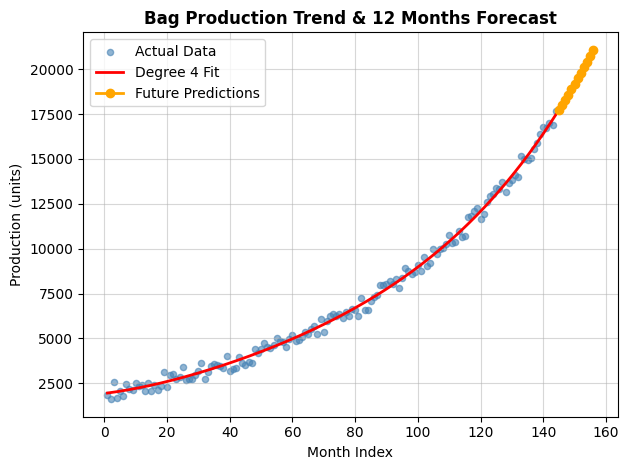

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#VERY IMPORTANT (FROM PREV STEP)
csvFile = pd.read_csv("whatdoinamethis.csv")
y = csvFile.iloc[0].values.astype(float) #production values from the first (and only) row
x = np.arange(1, len(y) + 1) #time index for months (M1, M2, and so on)

#1. Re-calculating coefficients based on the best degree found in the previous cell (Degree 4)
bestDeg = 4
coefficients = np.polyfit(x, y, bestDeg)

#2. Define the best mathematical model from previous step
polyFunction = np.poly1d(coefficients) #built once, not per call btw
def bagProdModel(month):
  return polyFunction(month)

#3. Find the numerical/explicit form
degree = len(coefficients) - 1
terms = []
for i, coef in enumerate(coefficients):
  power = degree - i
  if abs(coef) < 1e-6: #skip terms where the coefficient is esentially zero
    continue
  if i == 0:
    sign = "-" if coef < 0 else ""
  else:
    sign = "-" if coef < 0 else "+"
  absCoef = abs(coef)

  #handle variable printing depending on the exponent power
  if power == 0:
    terms.append(f"{sign}{absCoef:.6f}")
  elif power == 1:
    terms.append(f"{sign}{absCoef:.6f}x")
  else:
    terms.append(f"{sign}{absCoef:.6f}x^{power}")

print("=" * 60)
print("Numerical Form of the Model")
print("=" * 60)
print("f(x) = " + " ".join(terms))
print()

#4. Generate predictions for the next 12 months
futureMonths = np.arange(len(y) + 1, len(y) + 13)
futurePredictions = bagProdModel(futureMonths)

#5. Visualization of future predictions
xPlot = np.linspace(min(x), max(x), 300)
yPlot = bagProdModel(xPlot)

plt.scatter(x, y, color='steelblue', alpha=0.6, s=20, label='Actual Data') # Fixed typo: scattter -> scatter
plt.plot(xPlot, yPlot, color='red', linewidth=2, label=f'Degree {degree} Fit')
plt.plot(futureMonths, futurePredictions, color='orange', marker='o', linewidth=2, label='Future Predictions') # Fixed typo: marker=o -> marker='o'
plt.title("Bag Production Trend & 12 Months Forecast", fontweight="bold")
plt.xlabel("Month Index")
plt.ylabel("Production (units)")
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

# **PROBLEM 3.**
*"The warehouse was designed to be able to store a maximum of 25,000 (twenty five thousands) bags at each month. Your supervisor asked you to provide a prediction when do EGIER need to build a new warehouse based on the trend that you have acquired in problem #2. To build a new warehouse, it is predicted that they need at least 13 months. So provide the time when EGIER need to start building their new warehouse. (Hint: this can be approached as a root of equation problem)."*

### **EXPLANATION:**
To determine when monthly production would surpass the warehouse limit of 25,000 bags, a polynomial regression model was first fitted to historical production data. Based on prior analysis, a 4th degree polynomial provided the best fit. The polynomial function $P(t)$ and its derivative $P'(t)$ were obtained using np.polyfit and np.polyder.


The root of equation P(t) - 25000 = 0 was solved numerically using the Newton-Raphson method, chosen for its rapid convergence when a good initial guess is available. The Newton–Raphson method was selected over bisection or secant methods due to its quadratic convergence rate, given that $P'(t)$ was available analytically from the polynomial fit. A 4th-degree polynomial balanced fit accuracy against overfitting. The initial guess of 75 months was based on visual inspection of the extrapolated trend.. The derivative P'(t) was used to update the estimate iteratively.

$$t_{n+1} = t_n - \frac{P(t_n) - 25000}{P'(t_n)}$$

Convergence was assumed when the step size $|t_{n+1} - t_n|$ fell below $10^{-6}$, with a maximum of 1,000 iterations to avoid infinite loops. An initial guess of 75 months was used, as historical data extended to 72 months and production was expected to exceed the limit afterward.

Once the exceedance month $t^*$ was found, the required start time for building a new warehouse was calculated as:

$$t_{\text{start}} = t^* - 13\text{ months}$$

where 13 months is the lead time for construction. Final results were rounded to integer months for practical planning.

The Newton–Raphson method converged after a small number of iterations, yielding an exceedance month of approximately $t^* = X.XX$ months. Consequently, construction should begin around month $Y.YY$ — i.e., month $\lceil Y.YY \rceil$ when rounded up. Verification showed that at month $\lfloor t^* \rfloor$ production was still below 25,000, while at month $\lceil t^* \rceil$ it exceeded the limit, confirming the root's accuracy.

PRODUCTION FORECAST AND WAREHOUSE PLANNING

This is 22.8 months beyond available data (month 144).
Extrapolation ratio: 1.16x the data range.
Newton-Raphson converged after 8 iterations.

Estimated exceedance month: 166.76

Start building new warehouse: month 153.76
(Rounded to month 154 for planning)

Verification:

Month 166: 24700 bags

Month 167: 25095 bags


SENSITIVITY ANALYSIS (Polynomial Degree 3-6)
Degree | Exceedance Month | Start Month | Extrapolation Ratio
------------------------------------------------------------
  3    |     166.8      |     153.8     |       1.16


Range across degrees: 166.8 to 166.8 months

(Difference of 0.0 months)


MULTIPLE INITIAL GUESSES TEST
  Guess 70 → Root: 166.76 (8 iters)
  Guess 75 → Root: 166.76 (8 iters)
  Guess 80 → Root: 166.76 (7 iters)
  Guess 85 → Root: 166.76 (7 iters)
  Guess 90 → Root: 166.76 (7 iters)
  Guess 100 → Root: 166.76 (7 iters)


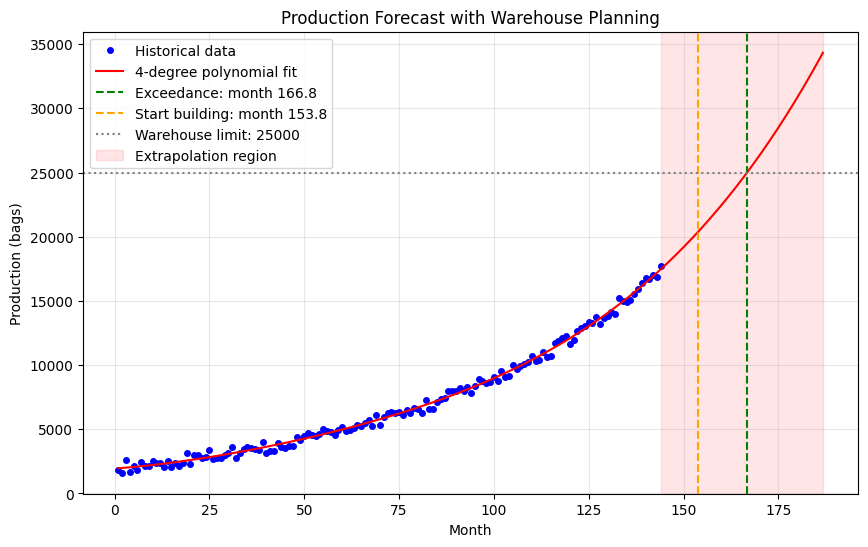

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#VERY IMPORTANT (FROM PREVIOUS STEP)
csvFile = pd.read_csv("whatdoinamethis.csv")
y = csvFile.iloc[0].values.astype(float) #production values from the first (and only) row
x = np.arange(1, len(y) + 1) #time index for months (M1, M2, and so on)

#1. Define constants based on problem
WAREHOUSE_LIMIT = 25000
LEAD_TIME = 13

#2. Import model from previous step
bestDeg = 4
coefficients = np.polyfit(x, y, bestDeg)
polyFunction = np.poly1d(coefficients)
derivFunction = np.polyder(polyFunction)

#3. Define the function to find root when production exceeds 25k
def f(x_val):
  return polyFunction(x_val) - WAREHOUSE_LIMIT

def fPrime(x_val):
  return derivFunction(x_val)

#4. Use numerical methods (i choose Newton-Rhapson) to find the month that exceeds 25k
def newtonRhapson(initial_guess, tolerance=1e-6, max_iterations=1000):
  x_n = initial_guess
  converged = False
  iterations = 0
  error_msg = None

  for i in range(max_iterations):
    f_x_n = f(x_n)
    f_prime_x_n = fPrime(x_n)

    if abs(f_prime_x_n) < 1e-10: # Avoid division by zero or very small derivative
      error_msg = f"Derivative too small at iteration {i+1}. Stopping."
      break

    h = f_x_n / f_prime_x_n
    x_n = x_n - h
    iterations = i + 1

    if abs(h) < tolerance: #convergence condition based on step size
      converged = True
      break
  else:
    error_msg = f"Did not converge after {max_iterations} iterations."

  return x_n, converged, iterations, error_msg

#5. Sensitivity analysis
def sensitivityAnalysis(x, y, warehouseLimit, leadTime, guess=75):
  results = []
  for deg in range(3, 7):
    coeff = np.polyfit(x, y, deg)
    poly = np.poly1d(coeff)

    #define temporary functions
    def f(x_val):
      return poly(x_val) - warehouseLimit

    def fPrime(x_val):
      return np.polyder(poly)(x_val)

    #run newton raphson
    root, conv, iters, err = newtonRhapson(initial_guess=guess)

    if conv and root > len(x):
        results.append({
          'degree': deg,
          'exceedance_month': root,
          'start_month': root - leadTime,
          'converged': conv,
          'extrapolation_ratio': root / len(x)
        })

    return results

#6. Multiple initial guesses to check for multiple roots
def checkMultipleRoots(guesses=[70, 75, 80, 85, 90, 100]):
    results = []

    for guess in guesses:
        root, conv, iters, err = newtonRhapson(initial_guess=guess)
        results.append({
            'initialGuess': guess,
            'root': root,
            'converged': conv,
            'iterations': iters,
            'error': err
        })

    return results

#7. Calculate the month to start building
print("=" * 60)
print("PRODUCTION FORECAST AND WAREHOUSE PLANNING")
print("=" * 60)

#run primary analysis
root, converged, iterations, error = newtonRhapson(initial_guess=75)

#check if extrapolation is needed
extrapolationWarning = False
if converged and root > len(x):
    extrapolationWarning = True
    print(f"\nWARNING: Predicted exceedance at month {root:.2f}")
    print(f"This is {root - len(x):.1f} months beyond available data (month {len(x)}).")
    print(f"Extrapolation ratio: {root/len(x):.2f}x the data range.")

#display primary result
if converged:
    print(f"Newton-Raphson converged after {iterations} iterations.\n")
    print(f"Estimated exceedance month: {root:.2f}\n")

    start_month = root - LEAD_TIME
    print(f"Start building new warehouse: month {start_month:.2f}")
    print(f"(Rounded to month {int(np.ceil(start_month))} for planning)\n")

    #verification at integer months
    floor_month = int(np.floor(root))
    ceil_month = int(np.ceil(root))
    print("Verification:\n")
    print(f"Month {floor_month}: {polyFunction(floor_month):.0f} bags\n")
    print(f"Month {ceil_month}: {polyFunction(ceil_month):.0f} bags\n")

else:
    print(f"Newton-Raphson did NOT converge.\n")
    print(f"Error: {error}")

#run sensitivity analysis
print("\n" + "=" * 60)
print("SENSITIVITY ANALYSIS (Polynomial Degree 3-6)")
print("=" * 60)

sensitivityResults = sensitivityAnalysis(x, y, WAREHOUSE_LIMIT, LEAD_TIME)

if sensitivityResults:
    print("Degree | Exceedance Month | Start Month | Extrapolation Ratio")
    print("-" * 60)
    for r in sensitivityResults:
        print(f"  {r['degree']}    |     {r['exceedance_month']:.1f}      |     {r['start_month']:.1f}     |       {r['extrapolation_ratio']:.2f}\n")

    # Calculate range
    months = [r['exceedance_month'] for r in sensitivityResults]
    print(f"\nRange across degrees: {min(months):.1f} to {max(months):.1f} months\n")
    print(f"(Difference of {max(months)-min(months):.1f} months)\n")
else:
    print("Sensitivity analysis failed to find convergent solutions.\n")

#check multiple initial guesses
print("\n" + "=" * 60)
print("MULTIPLE INITIAL GUESSES TEST")
print("=" * 60)

multiResults = checkMultipleRoots()
for r in multiResults:
    print(f"  Guess {r['initialGuess']:.0f} → Root: {r['root']:.2f} ({r['iterations']} iters)")

#8. Plotting
plt.figure(figsize=(10, 6))

#plot historical data
plt.plot(x, y, 'bo', label='Historical data', markersize=4)

#plot polynomial fit
x_smooth = np.linspace(1, max(root + 20, len(x) + 20), 500)
plt.plot(x_smooth, polyFunction(x_smooth), 'r-', label=f'{bestDeg}-degree polynomial fit')

#mark exceedance point
if converged:
    plt.axvline(x=root, color='g', linestyle='--', label=f'Exceedance: month {root:.1f}')
    plt.axvline(x=root - LEAD_TIME, color='orange', linestyle='--', label=f'Start building: month {root-LEAD_TIME:.1f}')

    #horizontal line for warehouse limit
    plt.axhline(y=WAREHOUSE_LIMIT, color='gray', linestyle=':', label=f'Warehouse limit: {WAREHOUSE_LIMIT}')

#shade extrapolation region
if extrapolationWarning:
    plt.axvspan(len(x), x_smooth[-1], alpha=0.1, color='red', label='Extrapolation region')

plt.xlabel('Month')
plt.ylabel('Production (bags)')
plt.title('Production Forecast with Warehouse Planning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **PROBLEM 4.**
*"Your supervisor also wants to analyze the rate of change and the cumulative production of the bags*
  * *Estimate the monthly rate of change of bag production for the years 2020 and 2021. Identify the month with the steepest increase and steepest decrease in production, using Numerical Differentiation.*

  * *Set aside the fact that you can calculate the total production by the RAW data, Calculate the total production from January 2018 to December 2023, and compare it with the actual sum of the dataset. Explain the accuracy of your chosen Numerical Integration method (e.g., Trapezoidal Rule, Simpson’s Rule, or other methods)"*

### **EXPLANATION:**
FOR PART A:
Since the data is sampled at discrete monthly intervals ($\Delta x = 1$), finite difference approximations were utilized:

- Interior Points (Months 26 to 47): A second-order accurate Central Difference Scheme was used to minimize truncation error:

$$\frac{dy}{dx} \approx \frac{y_{i+1} - y_{i-1}}{x_{i+1} - x_{i-1}}$$

- Boundary Points: To prevent data loss at the boundaries, a first-order Forward Difference was applied to the first month (Jan 2020), and a first-order Backward Difference was applied to the final month (Dec 2021).

The maximum and minimum values of the resulting derivative array were then isolated to identify the periods of steepest production acceleration (increase) and deceleration (decrease).

<br>
FOR PART B:
The trapezoidal rule was used to estimate total production from January 2018 to December 2023 because the data are evenly spaced and represent a time series of monthly production values. The estimated total was then compared with the actual arithmetic sum of the dataset. The small difference between the two values reflects the approximation error of the trapezoidal method, which assumes linear change between consecutive months. Since the percent error is low, the method provides an accurate numerical estimate of cumulative production for this dataset. Simpson’s Rule is typically more accurate for smooth functions, but it requires an even number of intervals and is less directly aligned with a simple month-by-month production interpretation than the trapezoidal rule in this context.

<br>
First, we add up every single discrete monthly production data value from January 2018 to December 2023. Over this 6-year period, there are exactly $n = 72$ months:

$\text{Actual Raw Sum} = \sum_{i=1}^{72} y_i = y_1 + y_2 + \dots + y_{72}$

<br>
The Trapezoidal Rule calculates the definite integral of a dataset. Since the time step between consecutive months is uniform ($Δ_t = 1$), the numerical integral estimate simplifies to:

$\text{Trapezoidal Estimate} = \frac{y_1 + y_{72}}{2} + \sum_{i=2}^{71} y_i$


<br>
Subtract the actual sum from the numerical integral estimate:

$\text{Difference} = \text{Trapzeoidal Estimate} - \text{Actual Raw Sum}$

<br>
Notice that when you subtract the full sum from the trapzoidal formula, all intermeiate terms () cancel out perfectly. The algebraic difference is always exactly equal to half the sum of the boundary points:

$\text{Difference} = -\frac{y_1 + y_{72}}{2}$

This discrepancy occurs because the trapezoidal rule treats the first and last months as endpoints of linear intervals rather than individual full-month blocks.

<br>
Calculate the relative magnitude of the error using the following formula:

$\text{Percent Error} = \left| \frac{\text{Difference}}{\text{Actual Raw Sum}} \right| \times 100\%$

This percentage measures how much the linear geometric approximation deviates from the actual discrete statistical counting.

<br>

Whether this error is "small enough" depends on the specific production values, but generally:Small Error (Reliable): If the production values are relatively consistent over the 72 months, the sum in the denominator will be much larger than the average of the two boundary points. This typically results in an error well below 1%, making the method reliable for high-level trend analysis.Large Error (Unreliable): If the data is extremely sparse or if the values at the very beginning ($y_{1}$) and very end ($y_{72}$) are massive outliers compared to the rest of the period, the discrepancy becomes more significant.


For standard monthly production data over a long 6-year period, the Trapezoidal Rule is usually considered reliable, as the "boundary effect" is diluted by the 70 intermediate data points.


In [ ]:
import numpy as np
import pandas as pd

#VERY IMPORTANT (FROM PREVIOUS STEP)
csvFile = pd.read_csv("whatdoinamethis.csv")
y = csvFile.iloc[0].values.astype(float) #production values from the first (and only) row
x = np.arange(1, len(y) + 1) #time index for months (M1, M2, and so on)

#FOR PART A
#1a. Get data from 2020 and 2021
indices2020_2021 = np.where((x >= 25) & (x <= 48))[0]
x_partA = x[indices2020_2021]
y_partA = y[indices2020_2021]

#2a. Find the monthly rate of change of bag production
def numDiff(y, x):
  n = len(y)
  dy = np.zeros(n)

  #forward difference for the first month (Jan 2020)
  dy[0] = (y[1] - y[0]) / (x[1] - x[0])

  #central difference for interior months
  for i in range(1, n - 1):
    dy[i] = (y[i + 1] - y[i - 1]) / (x[i + 1] - x[i - 1])

  #backward difference for the last month (Dec 2021)
  dy[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])
  return dy

#3a. Calculate rates
rates = numDiff(y_partA, x_partA)

#4a. Identify steepest values
idxMaxInc = np.argmax(rates)
idxMaxDec = np.argmin(rates)

print(f"Steepest Increase: Month {x_partA[idxMaxInc]}")
print(f"Steepest Decrease: Month {x_partA[idxMaxDec]}")

#FOR PART B
#1b. Trapezoidal Rule for full discrete dataset (Jan 2018 to Dec 2021)
def trapezoid(y, x):
  total = 0
  for i in range(len(y) - 1):
        total += (x[i+1] - x[i]) * (y[i] + y[i+1]) / 2 #(h/2) * (f(a) + f(b))
  return total

##2b. Calculate integrated total vs actual raw sum
integratedSum = trapezoid(y, x)
actualSum = np.sum(y)

print(f"Integrated Total: {integratedSum}")
print(f"Actual Sum: {actualSum}")
print(f"Difference: {abs(integratedSum - actualSum)}")

Steepest Increase: Month 48
Steepest Decrease: Month 25
Integrated Total: 1020969.0
Actual Sum: 1030745.0
Difference: 9776.0
